# Binary Detection Lab - Solucion completa de los 4 puntos

Este cuaderno resuelve los cuatro archivos del laboratorio:

- `BinDetection_Lab_1.pdf`: umbral MAP y probabilidad de error.
- `BinDetection_Lab_2.pdf`: efecto de las probabilidades a priori.
- `BinDetection_Lab_3.pdf`: detector escalar contra detector matched-filter.
- `BinDetection_Lab_4.pdf`: detector MAP contra clasificadores de machine learning.

La solucion esta basada en el cuaderno `BinaryDetector.ipynb`. De ese cuaderno se reutiliza la misma idea central: una fuente binaria transmite simbolos reales, el canal agrega ruido AWGN, el receptor compara observaciones con un umbral MAP y, para bloques rectangulares, el matched-filter se implementa como un promedio o integrate-and-dump. En el punto 4 se retoma ademas la idea de `BinaryDetector` de entrenar una red neuronal tipo MLP para detectar simbolos binarios a partir de datos simulados.

Cada punto sigue la misma estructura:

1. Enunciado: que pide el PDF.
2. Solucion en palabras: interpretacion del problema.
3. Desarrollo matematico: formulas usadas.
4. Implementacion: codigo Python comentado.
5. Discusion: lectura corta de los resultados.


## Configuracion comun del laboratorio

Todos los puntos usan el mismo modelo binario AWGN:

$$
H_0: Y=a_0+\eta,
\qquad
H_1: Y=a_1+\eta,
$$

con ruido gaussiano

$$
\eta \sim \mathcal{N}(0,\sigma_\eta^2).
$$

Para que el notebook sea reproducible y comparable con `BinaryDetector`, usamos simbolos simetricos:

$$
a_0=-1, \qquad a_1=1,
$$

y desviacion estandar de ruido:

$$
\sigma_\eta=1.
$$

Cuando no se indique lo contrario, las probabilidades a priori son iguales:

$$
\pi_0=\pi_1=0.5.
$$


In [1]:
# ============================================================
# Configuracion comun, librerias y funciones auxiliares
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# Parametros comunes del modelo binario AWGN.
a0 = -1.0
a1 = 1.0
sigma_eta = 1.0
sigma_eta2 = sigma_eta**2
pi0 = 0.5
pi1 = 0.5

# Semilla comun para que las simulaciones sean reproducibles.
rng = np.random.default_rng(2026)

if a0 >= a1:
    raise ValueError("Se requiere a0 < a1 para usar una regla de umbral creciente.")

if not np.isclose(pi0 + pi1, 1.0):
    raise ValueError("Las probabilidades a priori deben sumar uno.")


def map_threshold(a0, a1, sigma2, prior0, prior1):
    """Umbral MAP para dos gaussianas con igual varianza."""
    return (a0 + a1) / 2 + (sigma2 / (a1 - a0)) * np.log(prior0 / prior1)


def error_probabilities_for_threshold(gamma, a0, a1, sigma, prior0, prior1):
    """Calcula P_FA, P_M y P_e para un umbral gamma."""
    p_fa = stats.norm.sf(gamma, loc=a0, scale=sigma)
    p_m = stats.norm.cdf(gamma, loc=a1, scale=sigma)
    p_e = prior0 * p_fa + prior1 * p_m
    return p_fa, p_m, p_e


def binary_metrics(y_true, y_pred):
    """Metricas pedidas: P_FA, P_M, P_D y P_e.

    Convencion:
    - etiqueta 0 corresponde a H0,
    - etiqueta 1 corresponde a H1.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    p_fa = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    p_m = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    p_d = 1.0 - p_m
    p_e = (fp + fn) / (tn + fp + fn + tp)
    return p_e, p_fa, p_m, p_d, np.array([[tn, fp], [fn, tp]])


def print_rows(headers, rows, widths=None):
    """Imprime tablas de texto sin depender de pandas."""
    if widths is None:
        widths = [max(len(str(x)) for x in col) for col in zip(headers, *rows)]
    print("  ".join(str(h).ljust(w) for h, w in zip(headers, widths)))
    print("  ".join("-" * w for w in widths))
    for row in rows:
        print("  ".join(str(x).ljust(w) for x, w in zip(row, widths)))

print("Parametros comunes")
print(f"a0 = {a0}")
print(f"a1 = {a1}")
print(f"sigma_eta = {sigma_eta}")
print(f"pi0 = {pi0}")
print(f"pi1 = {pi1}")


Parametros comunes
a0 = -1.0
a1 = 1.0
sigma_eta = 1.0
pi0 = 0.5
pi1 = 0.5


# Punto 1 - MAP Threshold and Error Probability

## Enunciado

El primer PDF pide verificar el detector MAP para deteccion binaria en AWGN. Las tareas son:

1. Derivar la regla de decision MAP entre $H_0$ y $H_1$.
2. Mostrar que el detector MAP se puede escribir como un test de umbral.
3. Obtener la expresion analitica del umbral $\gamma_{MAP}$ para gaussianas con igual varianza.
4. Implementar el detector MAP en Python.
5. Barrer el umbral $\gamma$ y calcular
   $$P_e(\gamma)=\pi_0P_{FA}(\gamma)+\pi_1P_M(\gamma).$$
6. Comparar el umbral numericamente optimo con el umbral MAP analitico.

Entregables pedidos: derivacion, expresion de $\gamma_{MAP}$, grafica de $P_e(\gamma)$, tabla con $\gamma_{MAP}$, umbral numerico, $P_{FA}$, $P_M$, $P_e$, y una discusion breve.

## Solucion en palabras

El receptor observa un valor ruidoso $Y$. Si $Y$ esta mas cerca del simbolo $a_1$, tiende a decidir $H_1$; si esta mas cerca de $a_0$, tiende a decidir $H_0$. Sin embargo, MAP no solo mira cercania: tambien considera que una hipotesis puede ser mas probable que la otra antes de observar el dato. Por eso el umbral puede moverse hacia la hipotesis menos probable, ampliando la region de decision de la hipotesis mas probable.


## Desarrollo matematico del punto 1

La regla MAP decide la hipotesis con mayor probabilidad posterior:

$$
P(H_1\mid y) \mathop{\gtrless}_{H_0}^{H_1} P(H_0\mid y).
$$

Usando Bayes:

$$
P(H_i\mid y)=\frac{p(y\mid H_i)P(H_i)}{p(y)}.
$$

Como $p(y)$ es comun a ambas hipotesis, se cancela:

$$
p(y\mid H_1)\pi_1 \mathop{\gtrless}_{H_0}^{H_1} p(y\mid H_0)\pi_0.
$$

Dividiendo por $p(y\mid H_0)\pi_1$ se obtiene el test de razon de verosimilitudes:

$$
\Lambda(y)=\frac{p(y\mid H_1)}{p(y\mid H_0)}
\mathop{\gtrless}_{H_0}^{H_1}
\frac{\pi_0}{\pi_1}.
$$

Bajo el modelo AWGN:

$$
p(y\mid H_i)=\frac{1}{\sqrt{2\pi\sigma_\eta^2}}
\exp\left[-\frac{(y-a_i)^2}{2\sigma_\eta^2}\right].
$$

Al tomar logaritmo de la razon de verosimilitudes:

$$
\ln\Lambda(y)=\frac{(y-a_0)^2-(y-a_1)^2}{2\sigma_\eta^2}.
$$

Expandiendo:

$$
\ln\Lambda(y)=\frac{a_1-a_0}{\sigma_\eta^2}
\left(y-\frac{a_0+a_1}{2}\right).
$$

Como $a_1>a_0$, esta expresion crece con $y$, por lo que el detector MAP se escribe como:

$$
Y \mathop{\gtrless}_{H_0}^{H_1} \gamma_{MAP},
$$

con

$$
\boxed{
\gamma_{MAP}=\frac{a_0+a_1}{2}+\frac{\sigma_\eta^2}{a_1-a_0}\ln\left(\frac{\pi_0}{\pi_1}\right)
}.
$$

Para un umbral cualquiera $\gamma$:

$$
P_{FA}(\gamma)=P(Y\ge \gamma\mid H_0)
=Q\left(\frac{\gamma-a_0}{\sigma_\eta}\right),
$$

$$
P_M(\gamma)=P(Y<\gamma\mid H_1)
=\Phi\left(\frac{\gamma-a_1}{\sigma_\eta}\right),
$$

por tanto:

$$
P_e(\gamma)=\pi_0P_{FA}(\gamma)+\pi_1P_M(\gamma).
$$


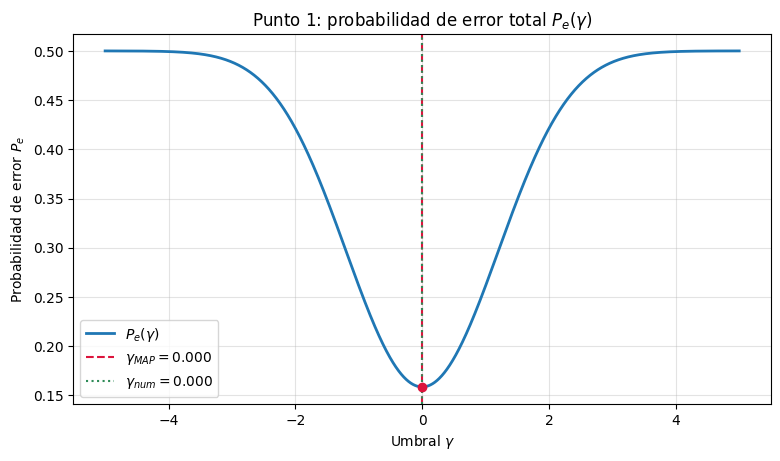

Quantity                            Value       
----------------------------------  ------------
gamma_MAP                           0.000000    
Numerically optimal threshold       0.000000    
P_FA at gamma_MAP                   0.158655    
P_M at gamma_MAP                    0.158655    
P_e at gamma_MAP                    0.158655    

Diferencia |gamma_numeric - gamma_MAP| = 0.000000e+00
P_e minimo numerico en la grilla = 0.158655


In [2]:
# ============================================================
# Punto 1 - Implementacion del detector MAP y barrido de umbral
# ============================================================

# 1. Umbral MAP analitico.
gamma_map = map_threshold(a0, a1, sigma_eta2, pi0, pi1)

# 2. Barrido de umbrales. Se toma un intervalo amplio alrededor de los dos simbolos.
threshold_values = np.linspace(a0 - 4 * sigma_eta, a1 + 4 * sigma_eta, 2001)

# 3. Probabilidades condicionales de error para cada umbral.
PFA_values = stats.norm.sf(threshold_values, loc=a0, scale=sigma_eta)
PM_values = stats.norm.cdf(threshold_values, loc=a1, scale=sigma_eta)
Pe_values = pi0 * PFA_values + pi1 * PM_values

# 4. Umbral que minimiza numericamente P_e en la grilla.
idx_min = np.argmin(Pe_values)
gamma_numeric = threshold_values[idx_min]
Pe_numeric = Pe_values[idx_min]

# 5. Probabilidades evaluadas exactamente en gamma_MAP.
PFA_map, PM_map, Pe_map = error_probabilities_for_threshold(
    gamma_map, a0, a1, sigma_eta, pi0, pi1
)

# 6. Grafica pedida: P_e(gamma) vs gamma.
plt.figure(figsize=(9, 4.8))
plt.plot(threshold_values, Pe_values, linewidth=2, label=r"$P_e(\gamma)$")
plt.axvline(gamma_map, linestyle="--", color="crimson", label=rf"$\gamma_{{MAP}}={gamma_map:.3f}$")
plt.axvline(gamma_numeric, linestyle=":", color="seagreen", label=rf"$\gamma_{{num}}={gamma_numeric:.3f}$")
plt.scatter([gamma_map], [Pe_map], color="crimson", zorder=3)
plt.xlabel(r"Umbral $\gamma$")
plt.ylabel(r"Probabilidad de error $P_e$")
plt.title(r"Punto 1: probabilidad de error total $P_e(\gamma)$")
plt.grid(True, alpha=0.35)
plt.legend()
plt.show()

# 7. Tabla requerida.
rows_p1 = [
    ("gamma_MAP", f"{gamma_map:.6f}"),
    ("Numerically optimal threshold", f"{gamma_numeric:.6f}"),
    ("P_FA at gamma_MAP", f"{PFA_map:.6f}"),
    ("P_M at gamma_MAP", f"{PM_map:.6f}"),
    ("P_e at gamma_MAP", f"{Pe_map:.6f}"),
]
print_rows(["Quantity", "Value"], rows_p1, widths=[34, 12])
print()
print(f"Diferencia |gamma_numeric - gamma_MAP| = {abs(gamma_numeric - gamma_map):.6e}")
print(f"P_e minimo numerico en la grilla = {Pe_numeric:.6f}")


## Discusion del punto 1

Con $a_0=-1$, $a_1=1$ y priors iguales, el umbral MAP es el punto medio:

$$
\gamma_{MAP}=0.
$$

El umbral numerico obtenido por barrido debe quedar muy cerca de cero. Si no coincide exactamente, la diferencia se debe a que el barrido evalua una grilla finita de valores de $\gamma$. En este caso el resultado analitico y el numerico concuerdan, lo que verifica la derivacion MAP.


# Punto 2 - Efecto de las probabilidades a priori

## Enunciado

El segundo PDF pide usar el mismo modelo binario AWGN, pero variando:

$$
\pi_1 \in \{0.1,0.3,0.5,0.7,0.9\},
\qquad
\pi_0=1-\pi_1.
$$

Para cada valor se debe:

1. Calcular $\gamma_{MAP}$.
2. Calcular $P_{FA}$, $P_M$ y $P_e$.
3. Graficar $\gamma_{MAP}$ contra $\pi_1$.
4. Graficar $P_{FA}$, $P_M$ y $P_e$ contra $\pi_1$.
5. Explicar por que el umbral se mueve hacia la hipotesis menos probable.
6. Discutir por que, con priors muy desbalanceadas y ruido alto, $\gamma_{MAP}$ puede salir del intervalo $[a_0,a_1]$.

## Solucion en palabras

Cuando $\pi_1$ aumenta, la hipotesis $H_1$ es mas probable antes de observar la muestra. MAP favorece entonces a $H_1$: baja el umbral para que sea mas facil decidir $H_1$. Ese desplazamiento ocurre hacia $H_0$, que ahora es la hipotesis menos probable. Lo mismo ocurre en sentido contrario cuando $\pi_1$ es pequena.


## Desarrollo matematico del punto 2

La formula del umbral es la misma del punto 1:

$$
\gamma_{MAP}(\pi_1)=\frac{a_0+a_1}{2}
+\frac{\sigma_\eta^2}{a_1-a_0}
\ln\left(\frac{1-\pi_1}{\pi_1}\right).
$$

El signo del logaritmo explica el movimiento del umbral:

- Si $\pi_1<0.5$, entonces $\pi_0>\pi_1$ y $\ln(\pi_0/\pi_1)>0$. El umbral sube hacia $a_1$, que es la hipotesis menos probable.
- Si $\pi_1>0.5$, entonces $\pi_0<\pi_1$ y $\ln(\pi_0/\pi_1)<0$. El umbral baja hacia $a_0$, que es la hipotesis menos probable.

Con ruido alto, el factor $\sigma_\eta^2/(a_1-a_0)$ crece. Por eso el desplazamiento causado por las priors puede ser tan grande que el umbral salga de $[a_0,a_1]$.


pi1     pi0     gamma_MAP     P_FA        P_M         P_e       
------  ------  ------------  ----------  ----------  ----------
0.1     0.9     1.098612      0.017926    0.539277    0.070061  
0.3     0.7     0.423649      0.077274    0.282189    0.138749  
0.5     0.5     0.000000      0.158655    0.158655    0.158655  
0.7     0.3     -0.423649     0.282189    0.077274    0.138749  
0.9     0.1     -1.098612     0.539277    0.017926    0.070061  


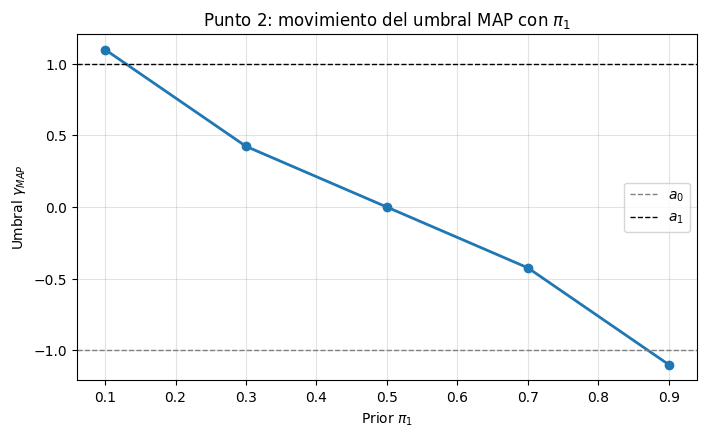

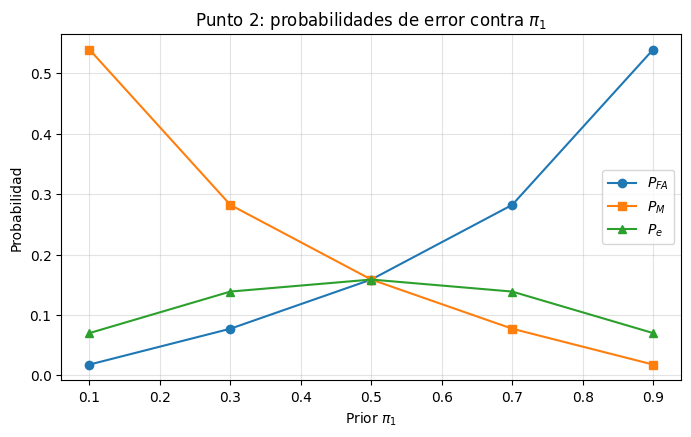

Ejemplo con sigma_eta = 2.0 para observar salida del intervalo [a0, a1]:
pi1=0.1 -> gamma_MAP=4.394 | fuera de [a0,a1]: True
pi1=0.3 -> gamma_MAP=1.695 | fuera de [a0,a1]: True
pi1=0.5 -> gamma_MAP=0.000 | fuera de [a0,a1]: False
pi1=0.7 -> gamma_MAP=-1.695 | fuera de [a0,a1]: True
pi1=0.9 -> gamma_MAP=-4.394 | fuera de [a0,a1]: True


In [3]:
# ============================================================
# Punto 2 - Priors variables y probabilidades de error
# ============================================================

pi1_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
pi0_values = 1.0 - pi1_values

gamma_prior = map_threshold(a0, a1, sigma_eta2, pi0_values, pi1_values)
PFA_prior = stats.norm.sf(gamma_prior, loc=a0, scale=sigma_eta)
PM_prior = stats.norm.cdf(gamma_prior, loc=a1, scale=sigma_eta)
Pe_prior = pi0_values * PFA_prior + pi1_values * PM_prior

rows_p2 = []
for p1, p0, gamma, pfa, pm, pe in zip(pi1_values, pi0_values, gamma_prior, PFA_prior, PM_prior, Pe_prior):
    rows_p2.append((f"{p1:.1f}", f"{p0:.1f}", f"{gamma:.6f}", f"{pfa:.6f}", f"{pm:.6f}", f"{pe:.6f}"))

print_rows(["pi1", "pi0", "gamma_MAP", "P_FA", "P_M", "P_e"], rows_p2,
           widths=[6, 6, 12, 10, 10, 10])

# Grafica 1: umbral MAP contra pi1.
plt.figure(figsize=(8, 4.5))
plt.plot(pi1_values, gamma_prior, marker="o", linewidth=2)
plt.axhline(a0, linestyle="--", color="gray", linewidth=1, label=r"$a_0$")
plt.axhline(a1, linestyle="--", color="black", linewidth=1, label=r"$a_1$")
plt.xlabel(r"Prior $\pi_1$")
plt.ylabel(r"Umbral $\gamma_{MAP}$")
plt.title(r"Punto 2: movimiento del umbral MAP con $\pi_1$")
plt.grid(True, alpha=0.35)
plt.legend()
plt.show()

# Grafica 2: probabilidades de error contra pi1.
plt.figure(figsize=(8, 4.5))
plt.plot(pi1_values, PFA_prior, marker="o", label=r"$P_{FA}$")
plt.plot(pi1_values, PM_prior, marker="s", label=r"$P_M$")
plt.plot(pi1_values, Pe_prior, marker="^", label=r"$P_e$")
plt.xlabel(r"Prior $\pi_1$")
plt.ylabel("Probabilidad")
plt.title(r"Punto 2: probabilidades de error contra $\pi_1$")
plt.grid(True, alpha=0.35)
plt.legend()
plt.show()

# Ejemplo adicional para mostrar salida del intervalo [a0, a1] con ruido alto.
high_noise_sigma = 2.0
high_noise_sigma2 = high_noise_sigma**2
gamma_high_noise = map_threshold(a0, a1, high_noise_sigma2, pi0_values, pi1_values)

print("Ejemplo con sigma_eta = 2.0 para observar salida del intervalo [a0, a1]:")
for p1, gamma in zip(pi1_values, gamma_high_noise):
    outside = gamma < a0 or gamma > a1
    print(f"pi1={p1:.1f} -> gamma_MAP={gamma:.3f} | fuera de [a0,a1]: {outside}")


## Discusion del punto 2

La tabla y las graficas muestran el compromiso entre falsa alarma y omision. Cuando $\pi_1$ aumenta, el umbral disminuye, por lo que se decide $H_1$ con mas facilidad. Esto aumenta $P_{FA}$ y reduce $P_M$. La probabilidad total de error $P_e$ no es simplemente el promedio de esos dos errores: cada uno se pondera por su prior.

La salida del intervalo $[a_0,a_1]$ no es un error matematico. Significa que, debido a priors muy desbalanceadas y ruido alto, MAP puede preferir casi siempre la hipotesis mas probable, porque el dato observado aporta poca evidencia confiable frente a la informacion previa.


# Punto 3 - Detector escalar vs matched-filter

## Enunciado

El tercer PDF pide comparar dos detectores para simbolos rectangulares repetidos de longitud $L$:

$$
r_k[n]=a_k+\eta_k[n],\qquad n=0,1,\ldots,L-1.
$$

El detector escalar usa solo una muestra:

$$
Y_k=r_k[0].
$$

El matched-filter, o integrate-and-dump, usa el promedio del bloque:

$$
Z_k=\frac{1}{L}\sum_{n=0}^{L-1} r_k[n].
$$

Se debe repetir el experimento para:

$$
L\in\{1,2,4,8,16,32,64\}.
$$

Entregables: derivacion de $Z_k$, derivacion de la varianza efectiva, tabla con $L$, errores empiricos y ganancia teorica, grafica de error contra $L$, y explicacion de por que el matched-filter mejora.

## Solucion en palabras

El detector escalar ignora casi todo el bloque recibido. Si cada simbolo dura $L$ muestras, usar una sola muestra desperdicia informacion. El matched-filter suma o promedia todas las muestras del simbolo; como el simbolo se mantiene constante y el ruido cambia de muestra a muestra, el promedio conserva el simbolo y reduce el ruido.


## Desarrollo matematico del punto 3

Partiendo de:

$$
r_k[n]=a_k+\eta_k[n],
$$

la estadistica matched-filter normalizada es:

$$
Z_k=\frac{1}{L}\sum_{n=0}^{L-1}r_k[n]
=\frac{1}{L}\sum_{n=0}^{L-1}(a_k+\eta_k[n]).
$$

Como $a_k$ es constante dentro del bloque:

$$
Z_k=a_k+\frac{1}{L}\sum_{n=0}^{L-1}\eta_k[n].
$$

Si las muestras de ruido son independientes y cada una tiene varianza $\sigma_\eta^2$, entonces:

$$
\operatorname{Var}\left(\frac{1}{L}\sum_{n=0}^{L-1}\eta_k[n]\right)
=\frac{1}{L^2}\sum_{n=0}^{L-1}\operatorname{Var}(\eta_k[n])
=\frac{L\sigma_\eta^2}{L^2}
=\frac{\sigma_\eta^2}{L}.
$$

Por tanto:

$$
Z_k\mid H_i \sim \mathcal{N}\left(a_i,\frac{\sigma_\eta^2}{L}\right).
$$

La ganancia teorica de procesamiento es:

$$
G_{MF}=10\log_{10}(L)\;\text{dB}.
$$


L      P_e scalar    P_e matched    var(Z)      G_MF [dB]  
-----  ------------  -------------  ----------  -----------
1      0.158520      0.158520       1.000000    0.00       
2      0.158480      0.079610       0.500000    3.01       
4      0.157450      0.022520       0.250000    6.02       
8      0.158740      0.002450       0.125000    9.03       
16     0.158210      0.000030       0.062500    12.04      
32     0.157680      0.000000       0.031250    15.05      
64     0.158580      0.000000       0.015625    18.06      


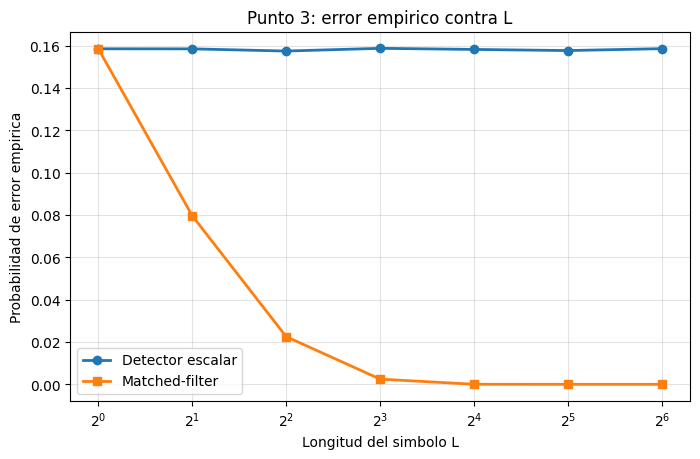

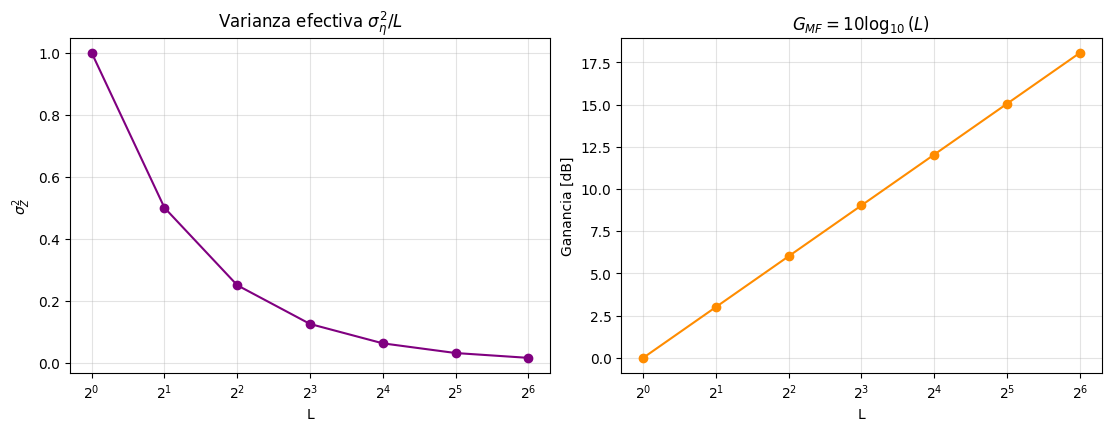

In [4]:
# ============================================================
# Punto 3 - Simulacion escalar vs matched-filter
# ============================================================

L_values = np.array([1, 2, 4, 8, 16, 32, 64])
N_symbols = 100_000
threshold_equal_priors = map_threshold(a0, a1, sigma_eta2, 0.5, 0.5)

error_scalar = []
error_matched = []
var_Z = []
gain_db = []

for L in L_values:
    # 1. Generar etiquetas binarias equiprobables.
    labels = rng.choice([0, 1], size=N_symbols, p=[0.5, 0.5])
    symbols = np.where(labels == 0, a0, a1)

    # 2. Generar bloques recibidos. Cada fila es un simbolo de longitud L.
    noise = rng.normal(0.0, sigma_eta, size=(N_symbols, L))
    received_blocks = symbols[:, None] + noise

    # 3. Detector escalar: usa solamente la primera muestra.
    Y = received_blocks[:, 0]
    pred_scalar = (Y >= threshold_equal_priors).astype(int)

    # 4. Detector matched-filter: usa el promedio del bloque.
    Z = received_blocks.mean(axis=1)
    pred_matched = (Z >= threshold_equal_priors).astype(int)

    # 5. Errores empiricos.
    error_scalar.append(np.mean(pred_scalar != labels))
    error_matched.append(np.mean(pred_matched != labels))
    var_Z.append(sigma_eta2 / L)
    gain_db.append(10 * np.log10(L))

error_scalar = np.array(error_scalar)
error_matched = np.array(error_matched)
var_Z = np.array(var_Z)
gain_db = np.array(gain_db)

rows_p3 = []
for L, es, em, vz, g in zip(L_values, error_scalar, error_matched, var_Z, gain_db):
    rows_p3.append((str(L), f"{es:.6f}", f"{em:.6f}", f"{vz:.6f}", f"{g:.2f}"))

print_rows(["L", "P_e scalar", "P_e matched", "var(Z)", "G_MF [dB]"], rows_p3,
           widths=[5, 12, 13, 10, 11])

# Grafica pedida: probabilidad de error contra L.
plt.figure(figsize=(8, 4.8))
plt.plot(L_values, error_scalar, marker="o", linewidth=2, label="Detector escalar")
plt.plot(L_values, error_matched, marker="s", linewidth=2, label="Matched-filter")
plt.xscale("log", base=2)
plt.xlabel("Longitud del simbolo L")
plt.ylabel("Probabilidad de error empirica")
plt.title("Punto 3: error empirico contra L")
plt.grid(True, which="both", alpha=0.35)
plt.legend()
plt.show()

# Grafica de apoyo: varianza efectiva y ganancia.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].plot(L_values, var_Z, marker="o", color="purple")
axes[0].set_xscale("log", base=2)
axes[0].set_xlabel("L")
axes[0].set_ylabel(r"$\sigma_Z^2$")
axes[0].set_title(r"Varianza efectiva $\sigma_\eta^2/L$")
axes[0].grid(True, which="both", alpha=0.35)

axes[1].plot(L_values, gain_db, marker="o", color="darkorange")
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("L")
axes[1].set_ylabel("Ganancia [dB]")
axes[1].set_title(r"$G_{MF}=10\log_{10}(L)$")
axes[1].grid(True, which="both", alpha=0.35)
plt.show()


## Discusion del punto 3

El error del detector escalar se mantiene aproximadamente constante al aumentar $L$, porque siempre usa una sola muestra. En cambio, el matched-filter mejora rapidamente porque promedia $L$ muestras independientes de ruido. La media del simbolo no cambia, pero la varianza del ruido baja a $\sigma_\eta^2/L$. Por eso las distribuciones bajo $H_0$ y $H_1$ se separan mas en unidades de desviacion estandar, y la probabilidad de error disminuye.


# Punto 4 - MAP Detector versus Machine-Learning Detector

## Enunciado

El cuarto PDF pide comparar detectores estadisticos clasicos con detectores supervisados de machine learning. Se usa el mismo modelo de bloques:

$$
r_k[n]=a_k+\eta_k[n],\qquad n=0,1,\ldots,L-1.
$$

Se debe:

1. Generar un dataset etiquetado $\{(r_k,b_k)\}_{k=1}^{N}$, con $r_k\in\mathbb{R}^L$ y $b_k\in\{0,1\}$.
2. Separar datos en entrenamiento, validacion y prueba.
3. Implementar MAP escalar usando una muestra.
4. Implementar MAP matched-filter usando $Z_k=\frac{1}{L}\sum r_k[n]$.
5. Entrenar regresion logistica usando $Z_k$.
6. Entrenar un MLP usando $Z_k$.
7. Entrenar un MLP usando el bloque completo $r_k$.
8. Comparar con $P_e$, $P_{FA}$, $P_M$ y $P_D=1-P_M$.
9. Discutir si machine learning mejora o no al detector MAP.

## Relacion con `BinaryDetector.ipynb`

`BinaryDetector.ipynb` introduce un detector neuronal tipo MLP para clasificar simbolos binarios a partir de datos ruidosos. Tambien muestra que el matched-filter resume cada bloque rectangular en una estadistica $Z_k$. Este punto usa esa misma idea: se entrena un MLP con $Z_k$ y se compara contra detectores MAP. Ademas, se agrega otro MLP que recibe el bloque completo $r_k$ para verificar si aprender desde todas las muestras mejora frente al uso de la estadistica suficiente.

## Solucion en palabras

En este modelo AWGN gaussiano, el detector MAP conoce exactamente la distribucion de los datos. Por eso es el detector optimo bajo las hipotesis del modelo. Un clasificador supervisado puede aprender una frontera parecida, pero no deberia superar de forma sistematica al MAP si el modelo estadistico es correcto y la estadistica usada contiene toda la informacion relevante.


## Desarrollo matematico del punto 4

El dataset supervisado contiene pares:

$$
(r_k,b_k),
\qquad
r_k\in\mathbb{R}^L,
\qquad
b_k\in\{0,1\}.
$$

La etiqueta se define como:

$$
b_k=0 \Leftrightarrow a_k=a_0,
\qquad
b_k=1 \Leftrightarrow a_k=a_1.
$$

Los detectores MAP usan reglas de umbral:

$$
\hat b_{scalar}=\mathbf{1}\{r_k[0]\ge \gamma_{scalar}\},
$$

$$
\hat b_{MF}=\mathbf{1}\{Z_k\ge \gamma_{MF}\},
\qquad
Z_k=\frac{1}{L}\sum_{n=0}^{L-1}r_k[n].
$$

Para priors iguales:

$$
\gamma_{scalar}=\gamma_{MF}=\frac{a_0+a_1}{2}.
$$

La regresion logistica aprende:

$$
P(b=1\mid Z)=\sigma(wZ+c),
$$

donde $\sigma(\cdot)$ es la funcion sigmoide. El MLP reemplaza esa frontera lineal simple por una red feed-forward con capas ocultas. Las metricas se calculan con la matriz de confusion:

$$
P_{FA}=\frac{FP}{FP+TN},
\qquad
P_M=\frac{FN}{FN+TP},
\qquad
P_D=1-P_M,
\qquad
P_e=\frac{FP+FN}{N}.
$$


In [5]:
# ============================================================
# Punto 4A - Generacion del dataset y particiones
# ============================================================

L_ml = 8
N_total = 30_000
rng_ml = np.random.default_rng(2026)

# 1. Etiquetas binarias: 0 representa H0 y 1 representa H1.
labels_ml = rng_ml.choice([0, 1], size=N_total, p=[0.5, 0.5])
symbols_ml = np.where(labels_ml == 0, a0, a1)

# 2. Bloques recibidos r_k en R^L.
noise_ml = rng_ml.normal(0.0, sigma_eta, size=(N_total, L_ml))
received_blocks_ml = symbols_ml[:, None] + noise_ml

# 3. Estadistica matched-filter Z_k usada por BinaryDetector.
Z_ml = received_blocks_ml.mean(axis=1).reshape(-1, 1)

# 4. Particion estratificada: 60% entrenamiento, 20% validacion, 20% prueba.
X_train_full, X_temp_full, y_train, y_temp = train_test_split(
    received_blocks_ml,
    labels_ml,
    test_size=0.40,
    random_state=2026,
    stratify=labels_ml,
)

X_val_full, X_test_full, y_val, y_test = train_test_split(
    X_temp_full,
    y_temp,
    test_size=0.50,
    random_state=2026,
    stratify=y_temp,
)

# 5. Entradas escalares para modelos que usan Z_k o una sola muestra.
Z_train = X_train_full.mean(axis=1).reshape(-1, 1)
Z_val = X_val_full.mean(axis=1).reshape(-1, 1)
Z_test = X_test_full.mean(axis=1).reshape(-1, 1)

X_train_scalar = X_train_full[:, 0].reshape(-1, 1)
X_val_scalar = X_val_full[:, 0].reshape(-1, 1)
X_test_scalar = X_test_full[:, 0].reshape(-1, 1)

print("Descripcion del dataset generado")
print(f"N_total = {N_total}")
print(f"Longitud de bloque L = {L_ml}")
print(f"Forma de received_blocks_ml = {received_blocks_ml.shape}")
print(f"Forma de Z_ml = {Z_ml.shape}")
print()
print("Particiones")
print(f"Entrenamiento: {X_train_full.shape[0]} muestras")
print(f"Validacion:    {X_val_full.shape[0]} muestras")
print(f"Prueba:        {X_test_full.shape[0]} muestras")
print()
print("Balance de clases")
print(f"P(H1) entrenamiento = {np.mean(y_train == 1):.4f}")
print(f"P(H1) validacion    = {np.mean(y_val == 1):.4f}")
print(f"P(H1) prueba        = {np.mean(y_test == 1):.4f}")


Descripcion del dataset generado
N_total = 30000
Longitud de bloque L = 8
Forma de received_blocks_ml = (30000, 8)
Forma de Z_ml = (30000, 1)

Particiones
Entrenamiento: 18000 muestras
Validacion:    6000 muestras
Prueba:        6000 muestras

Balance de clases
P(H1) entrenamiento = 0.4983
P(H1) validacion    = 0.4983
P(H1) prueba        = 0.4983


In [6]:
# ============================================================
# Punto 4B - Detectores analiticos y clasificadores ML
# ============================================================

# 1. Umbrales MAP. Con priors iguales y simbolos simetricos, ambos son 0.
gamma_scalar_ml = map_threshold(a0, a1, sigma_eta2, pi0, pi1)
gamma_mf_ml = map_threshold(a0, a1, sigma_eta2 / L_ml, pi0, pi1)

# 2. Regresion logistica usando Z_k.
logistic_z = LogisticRegression(random_state=2026, max_iter=1000)
logistic_z.fit(Z_train, y_train)

# 3. MLP usando Z_k. Esto sigue la idea de BinaryDetector: clasificar desde la estadistica matched-filter.
mlp_z = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    max_iter=800,
    random_state=2026,
)
mlp_z.fit(Z_train, y_train)

# 4. MLP usando el bloque completo r_k. Se estandariza cada columna para facilitar el entrenamiento.
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_val_full_scaled = scaler_full.transform(X_val_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

mlp_full = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    max_iter=800,
    random_state=2026,
)
mlp_full.fit(X_train_full_scaled, y_train)

print("Modelos entrenados")
print(f"gamma_scalar_MAP = {gamma_scalar_ml:.6f}")
print(f"gamma_matched_filter_MAP = {gamma_mf_ml:.6f}")
print(f"Regresion logistica coeficiente = {logistic_z.coef_[0, 0]:.6f}, intercepto = {logistic_z.intercept_[0]:.6f}")
print(f"MLP con Z_k: capas ocultas = {mlp_z.hidden_layer_sizes}, iteraciones = {mlp_z.n_iter_}")
print(f"MLP con r_k: capas ocultas = {mlp_full.hidden_layer_sizes}, iteraciones = {mlp_full.n_iter_}")


Modelos entrenados
gamma_scalar_MAP = 0.000000
gamma_matched_filter_MAP = 0.000000
Regresion logistica coeficiente = 11.095433, intercepto = -0.120084
MLP con Z_k: capas ocultas = (16, 8), iteraciones = 30
MLP con r_k: capas ocultas = (32, 16), iteraciones = 34


Chequeo en validacion
Detector                Input         P_e        P_FA       P_M        P_D      
----------------------  ------------  ---------  ---------  ---------  ---------
Scalar MAP              One sample    0.16167    0.16578    0.15753    0.84247  
Matched-filter MAP      Z_k           0.00217    0.00365    0.00067    0.99933  
Logistic regression     Z_k           0.00217    0.00299    0.00134    0.99866  
MLP                     Z_k           0.00217    0.00299    0.00134    0.99866  
MLP                     r_k           0.00267    0.00465    0.00067    0.99933  

Resultados finales en prueba
Detector                Input         P_e        P_FA       P_M        P_D      
----------------------  ------------  ---------  ---------  ---------  ---------
Scalar MAP              One sample    0.14783    0.14983    0.14582    0.85418  
Matched-filter MAP      Z_k           0.00267    0.00266    0.00268    0.99732  
Logistic regression     Z_k           0.00267    0.00266 

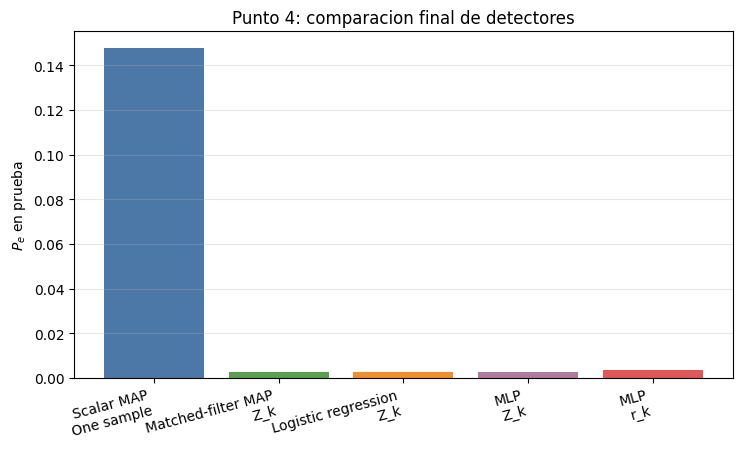

In [7]:
# ============================================================
# Punto 4C - Evaluacion de detectores y matrices de confusion
# ============================================================


def evaluate_all_detectors(X_scalar, Z, X_full_scaled, y_true):
    """Evalua todos los detectores pedidos sobre un mismo conjunto."""
    predictions = [
        ("Scalar MAP", "One sample", (X_scalar[:, 0] >= gamma_scalar_ml).astype(int)),
        ("Matched-filter MAP", "Z_k", (Z[:, 0] >= gamma_mf_ml).astype(int)),
        ("Logistic regression", "Z_k", logistic_z.predict(Z)),
        ("MLP", "Z_k", mlp_z.predict(Z)),
        ("MLP", "r_k", mlp_full.predict(X_full_scaled)),
    ]

    results = []
    matrices = {}
    for detector, input_name, y_pred in predictions:
        pe, pfa, pm, pd, cm = binary_metrics(y_true, y_pred)
        results.append((detector, input_name, pe, pfa, pm, pd))
        matrices[(detector, input_name)] = cm
    return results, matrices

validation_results, validation_matrices = evaluate_all_detectors(
    X_val_scalar, Z_val, X_val_full_scaled, y_val
)

test_results, test_matrices = evaluate_all_detectors(
    X_test_scalar, Z_test, X_test_full_scaled, y_test
)

print("Chequeo en validacion")
rows_val = [
    (det, inp, f"{pe:.5f}", f"{pfa:.5f}", f"{pm:.5f}", f"{pd:.5f}")
    for det, inp, pe, pfa, pm, pd in validation_results
]
print_rows(["Detector", "Input", "P_e", "P_FA", "P_M", "P_D"], rows_val,
           widths=[22, 12, 9, 9, 9, 9])

print("\nResultados finales en prueba")
rows_test = [
    (det, inp, f"{pe:.5f}", f"{pfa:.5f}", f"{pm:.5f}", f"{pd:.5f}")
    for det, inp, pe, pfa, pm, pd in test_results
]
print_rows(["Detector", "Input", "P_e", "P_FA", "P_M", "P_D"], rows_test,
           widths=[22, 12, 9, 9, 9, 9])

print("\nMatrices de confusion en prueba")
print("Formato: [[TN, FP], [FN, TP]]")
for key, cm in test_matrices.items():
    detector, input_name = key
    print(f"\n{detector} ({input_name})")
    print(cm)

# Grafica compacta de P_e en prueba.
plt.figure(figsize=(8.5, 4.5))
labels_plot = [f"{det}\n{inp}" for det, inp, *_ in test_results]
pe_plot = [pe for _, _, pe, _, _, _ in test_results]
plt.bar(labels_plot, pe_plot, color=["#4c78a8", "#59a14f", "#f28e2b", "#b07aa1", "#e15759"])
plt.ylabel(r"$P_e$ en prueba")
plt.title("Punto 4: comparacion final de detectores")
plt.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=15, ha="right")
plt.show()


## Discusion del punto 4

El matched-filter MAP y la regresion logistica con $Z_k$ suelen dar resultados casi iguales porque ambos usan la misma informacion escalar. En este problema gaussiano, $Z_k$ es una estadistica suficiente para el bloque rectangular: resume la informacion util del bloque para decidir entre $H_0$ y $H_1$.

El MLP con $Z_k$ aprende una frontera no lineal, pero como el problema optimo es esencialmente un umbral, no tiene informacion adicional para superar al MAP. El MLP con el bloque completo $r_k$ puede aprender una operacion parecida al promedio, pero necesita estimarla a partir de datos; por eso puede igualar aproximadamente al matched-filter, aunque no necesariamente superarlo.

La conclusion es la misma que sugiere `BinaryDetector.ipynb`: cuando el modelo estadistico es correcto y conocido, el detector MAP/matched-filter es la referencia optima. El aprendizaje supervisado reproduce ese detector cuando recibe datos suficientes y una entrada informativa. Puede fallar en mejorar porque no puede inventar informacion que no este en los datos, y porque el MAP ya incorpora la estructura exacta del modelo AWGN. Machine learning podria mejorar si el modelo asumido fuera incorrecto, si el ruido no fuera gaussiano, si hubiera distorsiones no modeladas, o si el canal tuviera no linealidades que el detector clasico no contempla.
